<a href="https://colab.research.google.com/github/vandana404/CUSTOMER-SEGMENTATION-CHURN-PREDICTION/blob/main/Advanced_CUSTOMER_SEGMENTATION_CHURN_PREDICTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df=pd.read_excel("/content/CHURN DATA.xlsx")

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
df.shape

(7043, 33)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [11]:
df['Churn Label'].value_counts()

,count
Churn Label,
No,5174
Yes,1869


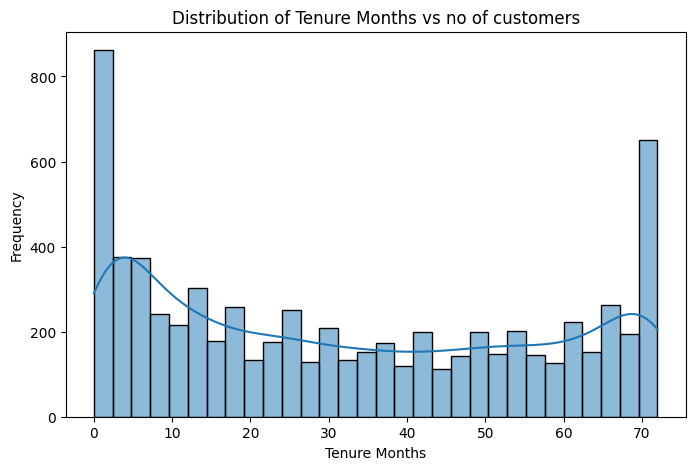

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df['Tenure Months'],bins=30,kde=True)
plt.xlabel('Tenure Months')
plt.ylabel('Frequency')
plt.title('Distribution of Tenure Months vs no of customers')
plt.show()

In [13]:
df['Tenure Months'].max()
df['Tenure Months'].min()

0

In [14]:
df['Tenure Months'].max()

72

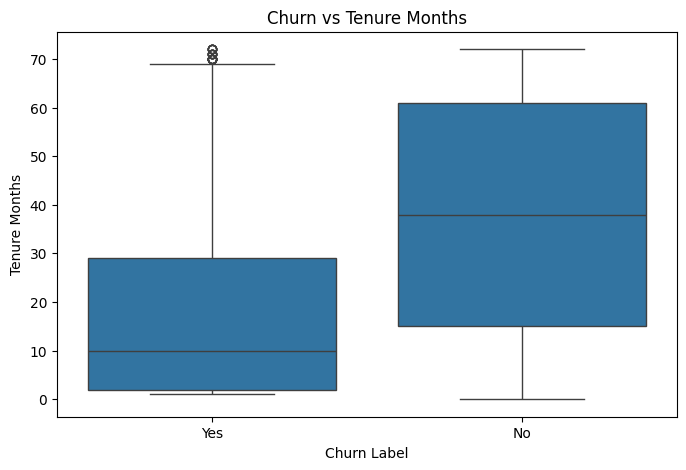

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn Label',y="Tenure Months",data=df)
plt.xlabel('Churn Label')
plt.ylabel('Tenure Months')
plt.title('Churn vs Tenure Months')
plt.show()

In [16]:
df['Churn Label'].unique()

array(['Yes', 'No'], dtype=object)

In [17]:
df[df['Churn Label']=='Yes']

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1864,1699-HPSBG,1,United States,California,Palm Springs,92264,"33.745746, -116.514215",33.745746,-116.514215,Male,...,One year,Yes,Electronic check,59.80,727.8,Yes,1,69,4581,Competitor offered higher download speeds
1865,8775-CEBBJ,1,United States,California,Seeley,92273,"32.790282, -115.689559",32.790282,-115.689559,Female,...,Month-to-month,Yes,Bank transfer (automatic),44.20,403.35,Yes,1,87,2029,Competitor offered higher download speeds
1866,6894-LFHLY,1,United States,California,Vidal,92280,"34.264124, -114.717964",34.264124,-114.717964,Male,...,Month-to-month,Yes,Electronic check,75.75,75.75,Yes,1,97,5571,Competitor offered higher download speeds
1867,0639-TSIQW,1,United States,California,White Water,92282,"33.972293, -116.654195",33.972293,-116.654195,Female,...,Month-to-month,Yes,Credit card (automatic),102.95,6886.25,Yes,1,70,5620,Competitor offered more data


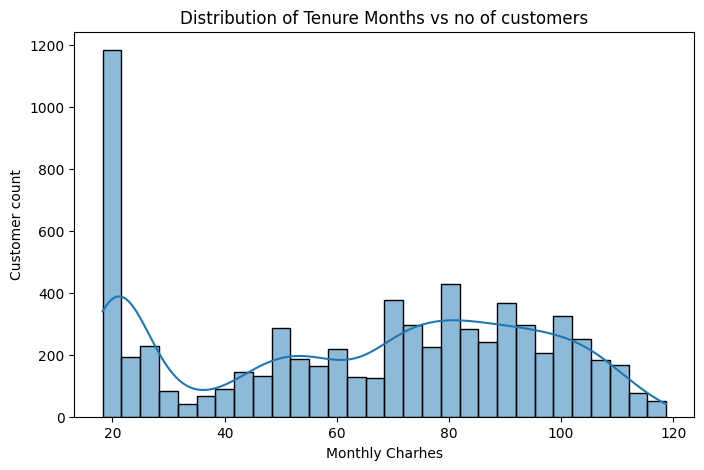

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df['Monthly Charges'],bins=30,kde=True)
plt.xlabel('Monthly Charhes')
plt.ylabel('Customer count')
plt.title('Distribution of Tenure Months vs no of customers')
plt.show()

In [19]:
df['Monthly Charges'].max()

118.75

In [20]:
df['Monthly Charges'].min()

18.25

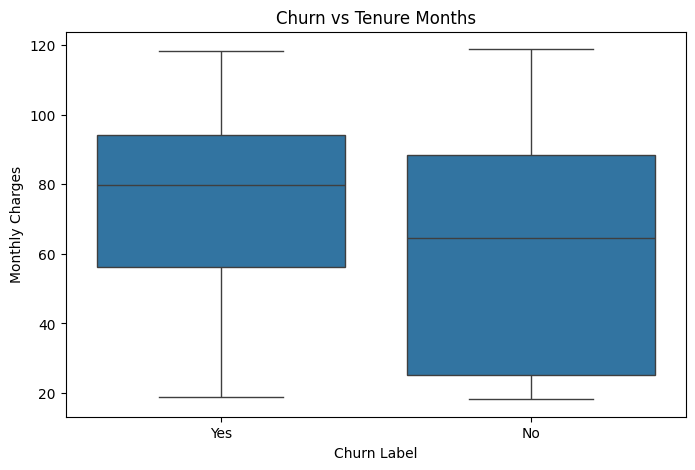

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn Label',y="Monthly Charges",data=df)
plt.xlabel('Churn Label')
plt.ylabel('Monthly Charges')
plt.title('Churn vs Tenure Months')
plt.show()

In [22]:
df[df['Churn Label']=='Yes']['Monthly Charges'].quantile([0.25,0.5,0.25])

,Monthly Charges
0.25,56.15
0.50,79.65
0.25,56.15


In [23]:
df['Monthly Charges'].describe()

,Monthly Charges
count,7043.000000
mean,64.761692
std,30.090047
min,18.250000
25%,35.500000
50%,70.350000
75%,89.850000
max,118.750000


In [24]:
df['Monthly Charges'].quantile([0.25,0.5,0.25])

,Monthly Charges
0.25,35.50
0.50,70.35
0.25,35.50


In [25]:
df['Contract'].unique()

array(['Month-to-month', 'Two year', 'One year'], dtype=object)

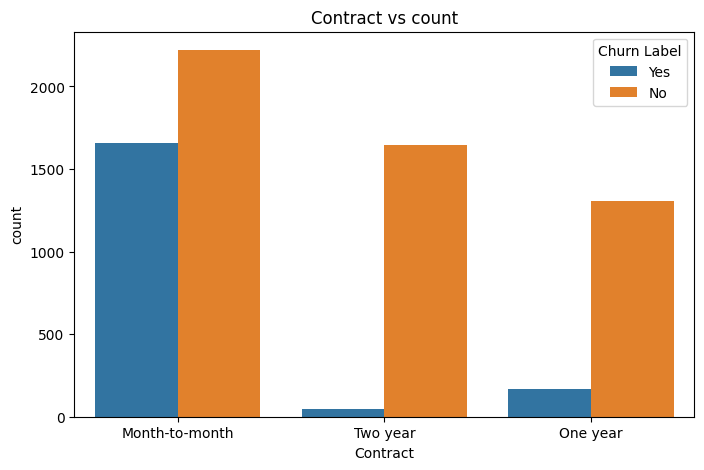

In [26]:
plt.figure(figsize=(8,5))
sns.countplot(x='Contract',hue='Churn Label',data=df)
plt.xlabel('Contract')
plt.ylabel('count')
plt.title('Contract vs count')
plt.show()

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [28]:
df['Internet Service'].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

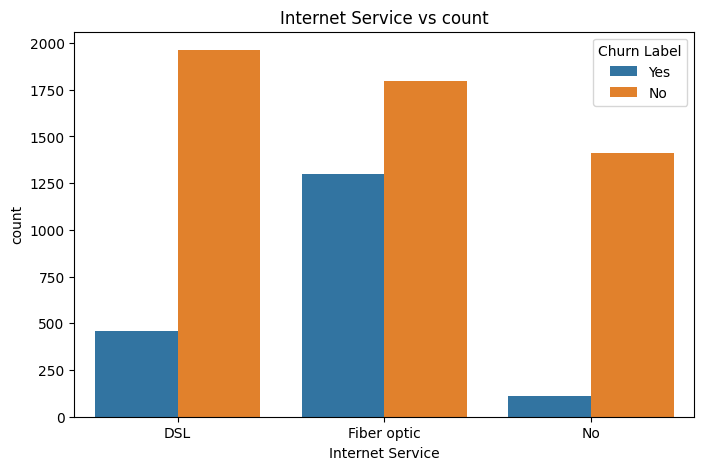

In [29]:
plt.figure(figsize=(8,5))
sns.countplot(x='Internet Service',hue='Churn Label',data=df)
plt.xlabel('Internet Service')
plt.ylabel('count')
plt.title('Internet Service vs count')
plt.show()

In [30]:
df['Payment Method'].unique()

array(['Mailed check', 'Electronic check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

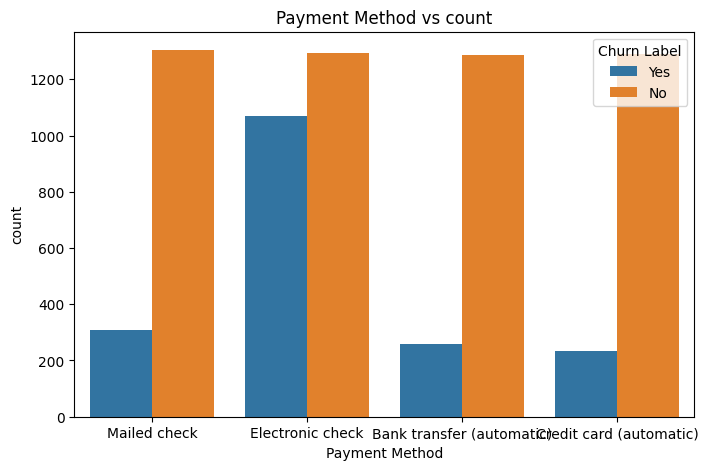

In [31]:
plt.figure(figsize=(8,5))
sns.countplot(x='Payment Method',hue='Churn Label',data=df)
plt.xlabel('Payment Method')
plt.ylabel('count')
plt.title('Payment Method vs count')
plt.show()

In [32]:
df['Tech Support'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

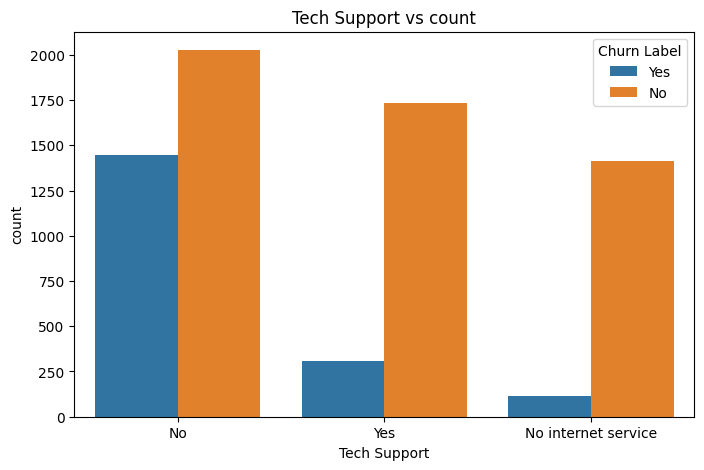

In [33]:
plt.figure(figsize=(8,5))
sns.countplot(x='Tech Support',hue='Churn Label',data=df)
plt.xlabel('Tech Support')
plt.ylabel('count')
plt.title('Tech Support vs count')
plt.show()

In [34]:
avg_tenure=df.groupby('Churn Label')['Tenure Months'].mean()

In [35]:
avg_tenure

,Tenure Months
Churn Label,
No,37.569965
Yes,17.979133


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [37]:
numericals_cols=['Tenure Months','Monthly Charges','Churn Value','Churn Score','CLTV']
np.correlation_matrix=df[numericals_cols].corr()

In [38]:
np.correlation_matrix

,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
Tenure Months,1.000000,0.247900,-0.352229,-0.224987,0.396406
Monthly Charges,0.247900,1.000000,0.193356,0.133754,0.098693
Churn Value,-0.352229,0.193356,1.000000,0.664897,-0.127463
Churn Score,-0.224987,0.133754,0.664897,1.000000,-0.079782
CLTV,0.396406,0.098693,-0.127463,-0.079782,1.000000


In [39]:
contract_churn=pd.crosstab(df['Contract'],df['Churn Label'],normalize='index')
contract_churn

Churn Label,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


DATA **CLEANING**

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [41]:
df['Total Charges']

,Total Charges
0,108.15
1,151.65
2,820.5
3,3046.05
4,5036.3
...,...
7038,1419.4
7039,1990.5
7040,7362.9
7041,346.45


In [42]:
df['Total Charges']=pd.to_numeric(df['Total Charges'],errors='coerce')

In [43]:
df['Total Charges']

,Total Charges
0,108.15
1,151.65
2,820.50
3,3046.05
4,5036.30
...,...
7038,1419.40
7039,1990.50
7040,7362.90
7041,346.45


In [44]:
df[df['Total Charges'].isnull()]['Tenure Months'].shape

(11,)

In [45]:
df['Total Charges']=df['Total Charges'].fillna(0)

In [46]:
drop_columns = [
    'CustomerID',
    'Count',
    'Country',
    'Zip Code',
    'State',
    'Longitude',
    'Lat Long',
    'Churn Label',
    'Churn Score',
    'CLTV',
    'Churn Reason'
]


df = df.drop(columns=drop_columns, errors='ignore')

In [47]:
df_encoded=pd.get_dummies(df,drop_first=True)

In [48]:
df_encoded.head()

,Latitude,Tenure Months,Monthly Charges,Total Charges,Churn Value,City_Acton,City_Adelanto,City_Adin,City_Agoura Hills,City_Aguanga,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,33.964131,2,53.85,108.15,1,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
1,34.059281,2,70.70,151.65,1,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
2,34.048013,8,99.65,820.50,1,False,False,False,False,False,...,False,True,False,True,False,False,True,False,True,False
3,34.062125,28,104.80,3046.05,1,False,False,False,False,False,...,False,True,False,True,False,False,True,False,True,False
4,34.039224,49,103.70,5036.30,1,False,False,False,False,False,...,False,True,False,True,False,False,True,False,False,False


In [49]:
df_encoded.shape

(7043, 1160)

In [50]:
df_encoded=pd.get_dummies(df,drop_first=True)

In [51]:
df.shape

(7043, 22)

In [52]:
x=df_encoded.drop('Churn Value',axis=1)
y=df_encoded['Churn Value']

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7043 non-null   object 
 1   Latitude           7043 non-null   float64
 2   Gender             7043 non-null   object 
 3   Senior Citizen     7043 non-null   object 
 4   Partner            7043 non-null   object 
 5   Dependents         7043 non-null   object 
 6   Tenure Months      7043 non-null   int64  
 7   Phone Service      7043 non-null   object 
 8   Multiple Lines     7043 non-null   object 
 9   Internet Service   7043 non-null   object 
 10  Online Security    7043 non-null   object 
 11  Online Backup      7043 non-null   object 
 12  Device Protection  7043 non-null   object 
 13  Tech Support       7043 non-null   object 
 14  Streaming TV       7043 non-null   object 
 15  Streaming Movies   7043 non-null   object 
 16  Contract           7043 

In [54]:
df_encoded=pd.get_dummies(df,drop_first=True)

In [55]:
df_encoded.shape

(7043, 1160)

In [56]:
x=df_encoded.drop('Churn Value',axis=1)
y=df_encoded['Churn Value']

In [57]:
x.shape
y.shape

(7043,)

In [58]:
print(x)

       Latitude  Tenure Months  Monthly Charges  Total Charges  City_Acton  \
0     33.964131              2            53.85         108.15       False   
1     34.059281              2            70.70         151.65       False   
2     34.048013              8            99.65         820.50       False   
3     34.062125             28           104.80        3046.05       False   
4     34.039224             49           103.70        5036.30       False   
...         ...            ...              ...            ...         ...   
7038  34.341737             72            21.15        1419.40       False   
7039  34.667815             24            84.80        1990.50       False   
7040  34.559882             72           103.20        7362.90       False   
7041  34.167800             11            29.60         346.45       False   
7042  34.424926             66           105.65        6844.50       False   

      City_Adelanto  City_Adin  City_Agoura Hills  City_Aguanga

In [59]:
print(y)

0       1
1       1
2       1
3       1
4       1
       ..
7038    0
7039    0
7040    0
7041    0
7042    0
Name: Churn Value, Length: 7043, dtype: int64


**MACHINE** **LEARNING**

In [60]:
from sklearn.model_selection import train_test_split

In [61]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42
)

In [62]:
y_train.shape

(5634,)

In [63]:
x_train.shape

(5634, 1159)

In [64]:
from sklearn.ensemble import RandomForestClassifier

In [65]:
rf_model=RandomForestClassifier(n_estimators=100,random_state=42)

In [66]:
rf_model.fit(x_train,y_train)

RandomForestClassifier(random_state=42)

In [67]:
y_pred=rf_model.predict(x_test)

In [68]:
y_pred

array([0, 0, 0, ..., 1, 0, 1])

In [69]:
from sklearn.metrics import accuracy_score

In [70]:
accuracy=accuracy_score(y_test,y_pred)
print(accuracy)

0.8005677785663591


In [71]:
from sklearn.metrics import confusion_matrix

In [72]:
cm=confusion_matrix(y_test,y_pred)

In [73]:
print(cm)

[[929  80]
 [201 199]]


In [74]:
from sklearn.metrics import classification_report

In [75]:
print (classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.82      0.92      0.87      1009
           1       0.71      0.50      0.59       400

    accuracy                           0.80      1409
   macro avg       0.77      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



APPROACH 1 HANDLE CLASS IMBALANCE

In [76]:
rf_balanced=RandomForestClassifier(n_estimators=100,random_state=42,class_weight='balanced')
rf_balanced.fit(x_train,y_train)
y_pred_balanced=rf_balanced.predict(x_test)
accuracy_balanced=accuracy_score(y_test,y_pred_balanced)
cm_balanced=confusion_matrix(y_test,y_pred_balanced)
print(accuracy_balanced)
print(cm_balanced)
print(classification_report(y_test,y_pred_balanced))

0.808374733853797
[[920  89]
 [181 219]]
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1009
           1       0.71      0.55      0.62       400

    accuracy                           0.81      1409
   macro avg       0.77      0.73      0.75      1409
weighted avg       0.80      0.81      0.80      1409



APPROACH 2-**HYPERPARAMETER**

In [77]:
rf_tuned=RandomForestClassifier(n_estimators=300,max_depth=10,random_state=42,class_weight='balanced')
rf_tuned.fit(x_train,y_train)
y_pred_tuned=rf_tuned.predict(x_test)
print(classification_report(y_test,y_pred_tuned))

              precision    recall  f1-score   support

           0       0.90      0.70      0.79      1009
           1       0.52      0.81      0.63       400

    accuracy                           0.73      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.79      0.73      0.74      1409



XGBOOST MODEL COMPARISION

In [78]:
!pip install xgboost

In [79]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

xgb.fit(x_train, y_train)

y_pred_xgb = xgb.predict(x_test)
y_prob_xgb = xgb.predict_proba(x_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1:", f1_score(y_test, y_pred_xgb))
print("ROC AUC:", roc_auc_score(y_test, y_prob_xgb))

Accuracy: 0.8034066713981547
Precision: 0.6858006042296072
Recall: 0.5675
F1: 0.6210670314637483
ROC AUC: 0.8604038652130822


LOGISTIC REGRESSION ANALYSIS

In [80]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(x_train, y_train)

y_pred_lr = lr.predict(x_test)
y_prob_lr = lr.predict_proba(x_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1:", f1_score(y_test, y_pred_lr))
print("ROC AUC:", roc_auc_score(y_test, y_prob_lr))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.7963094393186657
Precision: 0.6628242074927954
Recall: 0.575
F1: 0.6157965194109772
ROC AUC: 0.8476263627353815


APPROACH 3-**FEATURE** **IMPORTANCE** **IMPLEMENTATION** **ANALYSIS**

In [81]:
import pandas as pd


feature_importance = pd.DataFrame({
    'features': x.columns,
    'Importance': rf_tuned.feature_importances_
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)
print(feature_importance)

                             features  Importance
1                       Tenure Months    0.108323
1154                Contract_Two year    0.098450
3                       Total Charges    0.075121
1157  Payment Method_Electronic check    0.054798
1135                   Dependents_Yes    0.048742
...                               ...         ...
75                       City_Benicia    0.000000
282                     City_Dunsmuir    0.000000
457                    City_Inverness    0.000000
459                         City_Ione    0.000000
266                        City_Dixon    0.000000

[1159 rows x 2 columns]


In [82]:
print(feature_importance.tail(15))

              features  Importance
756  City_Paynes Creek         0.0
955        City_Sonora         0.0
606      City_Mcarthur         0.0
621      City_Midpines         0.0
967  City_Squaw Valley         0.0
649        City_Moraga         0.0
339  City_Forest Falls         0.0
345  City_Fort Bidwell         0.0
850  City_Rohnert Park         0.0
476         City_Keene         0.0
75        City_Benicia         0.0
282      City_Dunsmuir         0.0
457     City_Inverness         0.0
459          City_Ione         0.0
266         City_Dixon         0.0


In [83]:

x_selected = x.drop(['Phone Service_Yes', 'Multiple Lines_No phone service'], axis=1, errors='ignore')


In [84]:

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_selected, y, test_size=0.2, random_state=42)


In [85]:
rf_selected=RandomForestClassifier(n_estimators=300,max_depth=10,random_state=42,class_weight='balanced')
rf_selected.fit(x_train,y_train)
y_pred_selected=rf_selected.predict(x_test)
print(classification_report(y_test,y_pred_selected))

              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1009
           1       0.53      0.81      0.64       400

    accuracy                           0.74      1409
   macro avg       0.72      0.76      0.72      1409
weighted avg       0.80      0.74      0.75      1409



APPROACH 2-TREES OR DEPTH COMBINATION


In [86]:
n_estimators=[100,200,300,400,500]
max_depth=[5,10,15,20]
result=[]
for n_trees in n_estimators:
  for depth in max_depth:
    rf_model=RandomForestClassifier(n_estimators=n_trees,max_depth=depth,random_state=42,class_weight='balanced')
    rf_model.fit(x_train,y_train)
    y_pred=rf_model.predict(x_test)



In [87]:
from sklearn.metrics import accuracy_score,recall_score,precision_score,f1_score

In [88]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

n_estimators = [100, 200, 300, 400, 500]
max_depth = [5, 10, 15, 20]
result = []

for n_trees in n_estimators:
    for depth in max_depth:
        rf_model = RandomForestClassifier(
            n_estimators=n_trees,
            max_depth=depth,
            random_state=42,
            class_weight='balanced'
        )
        rf_model.fit(x_train, y_train)
        y_pred = rf_model.predict(x_test)

        accuracy = accuracy_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        result.append({
            'Trees': n_trees,
            'Depth': depth,
            'Accuracy': accuracy,
            'Recall': recall,
            'precision': precision,
            'F1 Score': f1
        })

result_df = pd.DataFrame(result)

result_df = result_df.sort_values(by=['Recall', 'Accuracy'], ascending=False)
print(result_df.head(20))


    Trees  Depth  Accuracy  Recall  precision  F1 Score
0     100      5  0.702626  0.8550   0.486486  0.620127
16    500      5  0.715401  0.8500   0.499266  0.629047
4     200      5  0.708304  0.8500   0.492041  0.623281
12    400      5  0.716111  0.8475   0.500000  0.628942
8     300      5  0.702626  0.8475   0.486370  0.618049
17    500     10  0.738112  0.8175   0.524880  0.639296
9     300     10  0.742370  0.8150   0.530081  0.642365
13    400     10  0.740951  0.8150   0.528363  0.641101
5     200     10  0.740951  0.8125   0.528455  0.640394
1     100     10  0.740951  0.8100   0.528548  0.639684
14    400     15  0.759404  0.7775   0.554367  0.647242
18    500     15  0.754436  0.7775   0.547535  0.642562
10    300     15  0.755145  0.7750   0.548673  0.642487
6     200     15  0.753016  0.7700   0.546099  0.639004
2     100     15  0.752307  0.7700   0.545133  0.638342
15    400     20  0.772179  0.7525   0.575526  0.652221
3     100     20  0.774308  0.7500   0.579151  0

In [89]:
from sklearn.model_selection import cross_val_score
final_rf=RandomForestClassifier(n_estimators=300,max_depth=10,random_state=42,class_weight='balanced')


In [90]:
cv_accuracy=cross_val_score(final_rf,x,y,cv=5,scoring='accuracy')

In [91]:
cv_accuracy

array([0.76224273, 0.76366217, 0.73740241, 0.74715909, 0.74431818])

In [92]:
cv_accuracy.mean()

np.float64(0.7509569165752629)

In [93]:
cv_recall=cross_val_score(final_rf,x,y,cv=5,scoring='recall')


In [94]:
cv_recall.mean()

np.float64(0.8180714254992759)

In [95]:
from sklearn.metrics import roc_auc_score,roc_curve

In [96]:
import matplotlib.pyplot as plt


In [97]:

x_test_aligned = x_test.reindex(columns=rf_tuned.feature_names_in_, fill_value=0)


y_prob = rf_tuned.predict_proba(x_test_aligned)

churn_prob = y_prob[:, 1]

print(churn_prob[:10])
print(rf_tuned.feature_names_in_)
print(x_test.columns)

[0.64970267 0.51828188 0.31539455 0.72098792 0.48619726 0.72997958
 0.73012113 0.56990359 0.65471337 0.14453566]
['Latitude' 'Tenure Months' 'Monthly Charges' ...
 'Payment Method_Credit card (automatic)'
 'Payment Method_Electronic check' 'Payment Method_Mailed check']
Index(['Latitude', 'Tenure Months', 'Monthly Charges', 'Total Charges',
       'City_Acton', 'City_Adelanto', 'City_Adin', 'City_Agoura Hills',
       'City_Aguanga', 'City_Ahwahnee',
       ...
       'Streaming TV_No internet service', 'Streaming TV_Yes',
       'Streaming Movies_No internet service', 'Streaming Movies_Yes',
       'Contract_One year', 'Contract_Two year', 'Paperless Billing_Yes',
       'Payment Method_Credit card (automatic)',
       'Payment Method_Electronic check', 'Payment Method_Mailed check'],
      dtype='object', length=1157)


In [98]:
churn_prob=y_prob[:,1]

In [99]:
churn_prob=y_prob[:,1]
fpr,tpr,thresholds=roc_curve(y_test,churn_prob)
auc_score=roc_auc_score(y_test,churn_prob)
print(auc_score)

0.8412710604558968


 ***CUSTOMER*** **SEGMENTATION**

In [100]:

Segmentio_Data = pd.DataFrame({
    'Tenure Months': x_test['Tenure Months'],
    'Monthly Charges': x_test['Monthly Charges'],
    'Total Charges': x_test['Total Charges'],
    'Churn Probability': churn_prob
})


In [101]:
Segmentio_Data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability
185,15,85.90,1269.55,0.649703
2715,18,56.80,1074.65,0.518282
3825,2,20.00,40.90,0.315395
1807,6,84.20,519.15,0.720988
132,40,104.80,4131.95,0.486197
...,...,...,...,...
6366,66,104.90,6891.45,0.432862
315,19,86.00,1532.45,0.655604
2439,2,90.35,190.50,0.638970
5002,68,110.20,7467.50,0.291009


***Implementation of kmeans***




In [102]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()


In [103]:
Segmentio_Data = pd.DataFrame({
    'Tenure Months': x_test['Tenure Months'],
    'Monthly Charges': x_test['Monthly Charges'],
    'Total Charges': x_test['Total Charges'],
    'Churn Probability': churn_prob
})


scaler = StandardScaler()
scaled_data = scaler.fit_transform(Segmentio_Data)

print(scaled_data.shape)

(1409, 4)


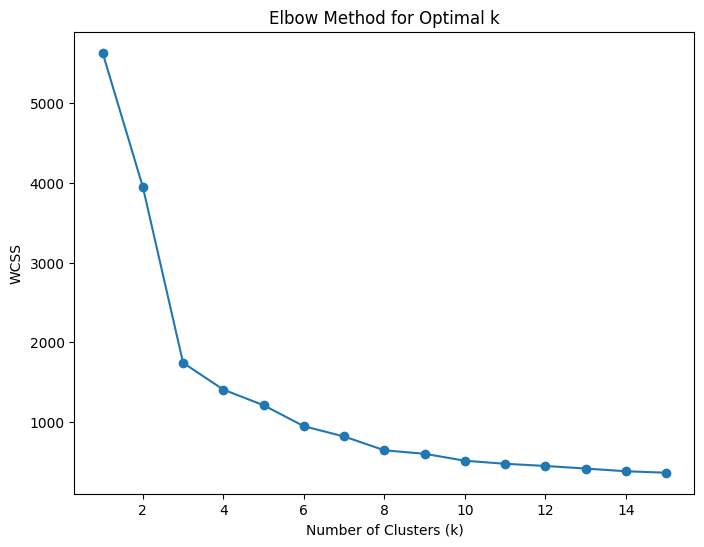

In [104]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []
for k in range(1, 16):

    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)

    wcss.append(kmeans.inertia_)


plt.figure(figsize=(8, 6))

plt.plot(range(1, 16), wcss, marker='o')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.show()


In [105]:

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(scaled_data)

KMeans(n_clusters=3, random_state=42)

In [106]:
clusters=kmeans.fit_predict(scaled_data)

In [107]:
Segmentio_Data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability
185,15,85.90,1269.55,0.649703
2715,18,56.80,1074.65,0.518282
3825,2,20.00,40.90,0.315395
1807,6,84.20,519.15,0.720988
132,40,104.80,4131.95,0.486197
...,...,...,...,...
6366,66,104.90,6891.45,0.432862
315,19,86.00,1532.45,0.655604
2439,2,90.35,190.50,0.638970
5002,68,110.20,7467.50,0.291009


In [108]:
Segmentio_Data['cluster']=clusters

In [109]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, roc_auc_score
scaler = StandardScaler()
Segmentio_Data = pd.DataFrame({
    'Tenure Months': x_test['Tenure Months'],
    'Monthly Charges': x_test['Monthly Charges'],
    'Total Charges': x_test['Total Charges'],
    'Churn Probability': churn_prob
})

scaled_data = scaler.fit_transform(Segmentio_Data)

sil_score = silhouette_score(scaled_data, clusters)
print(f"Mathematical Silhouette Score for 3 Clusters: {sil_score:.4f}")

Mathematical Silhouette Score for 3 Clusters: 0.4722


In [110]:
Segmentio_Data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability
185,15,85.90,1269.55,0.649703
2715,18,56.80,1074.65,0.518282
3825,2,20.00,40.90,0.315395
1807,6,84.20,519.15,0.720988
132,40,104.80,4131.95,0.486197
...,...,...,...,...
6366,66,104.90,6891.45,0.432862
315,19,86.00,1532.45,0.655604
2439,2,90.35,190.50,0.638970
5002,68,110.20,7467.50,0.291009


In [111]:

Segmentio_Data['clusters'] = kmeans.labels_

cluster_summary = Segmentio_Data.groupby('clusters').mean(numeric_only=True)

In [112]:
cluster_summary

,Tenure Months,Monthly Charges,Total Charges,Churn Probability
clusters,,,,
0,12.623140,72.488595,965.532149,0.624428
1,32.539510,27.542098,942.729837,0.218735
2,58.757437,89.631922,5275.488330,0.374729


In [113]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(scaled_data)

Segmentio_Data['cluster'] = clusters

print(Segmentio_Data.head())

      Tenure Months  Monthly Charges  Total Charges  Churn Probability  \
185              15             85.9        1269.55           0.649703   
2715             18             56.8        1074.65           0.518282   
3825              2             20.0          40.90           0.315395   
1807              6             84.2         519.15           0.720988   
132              40            104.8        4131.95           0.486197   

      clusters  cluster  
185          0        0  
2715         0        0  
3825         1        1  
1807         0        0  
132          2        2  


In [114]:
cluster_names={
    0:'Budget Loyal Customer',
    1:'High Risk Customer',
    2:'Loyal Premium Customer'
}

In [115]:

cluster_names = {
    0:'Budget Loyal Customer',
    1:'High Risk Customer',
    2:'Loyal Premium Customer'
}

Segmentio_Data['Cluster Segment'] = Segmentio_Data['cluster'].map(cluster_names)

In [116]:
plt.figure(figsize=(10,8))

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

<Axes: xlabel='Tenure Months', ylabel='Monthly Charges'>

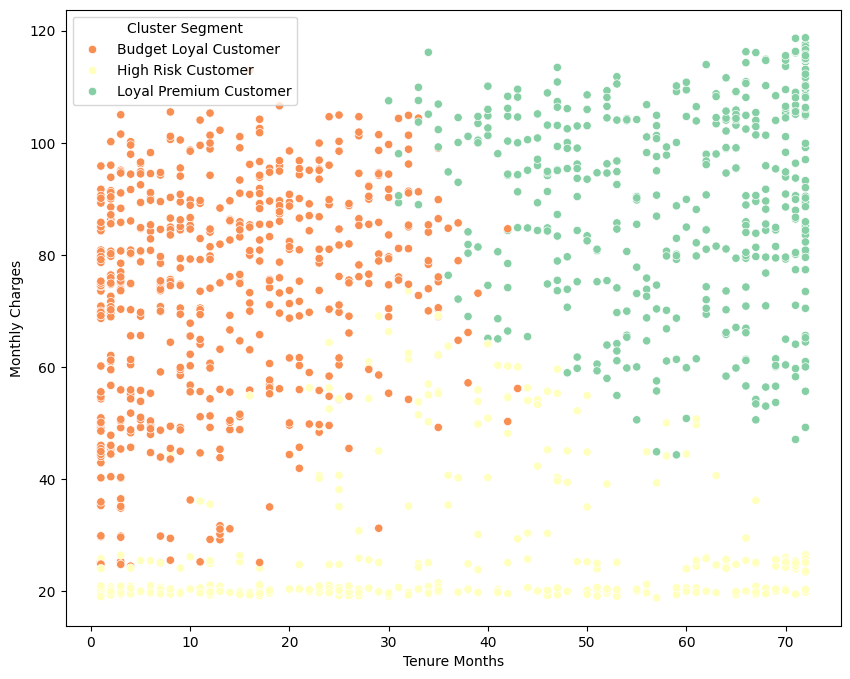

In [117]:
plt.figure(figsize=(10,8))
sns.scatterplot(x='Tenure Months',y='Monthly Charges',hue='Cluster Segment',data=Segmentio_Data,palette='Spectral')

PCA CLUSTER VISULAIZATION

In [118]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_result = pca.fit_transform(scaled_data)

Segmentio_Data["PCA1"] = pca_result[:,0]
Segmentio_Data["PCA2"] = pca_result[:,1]

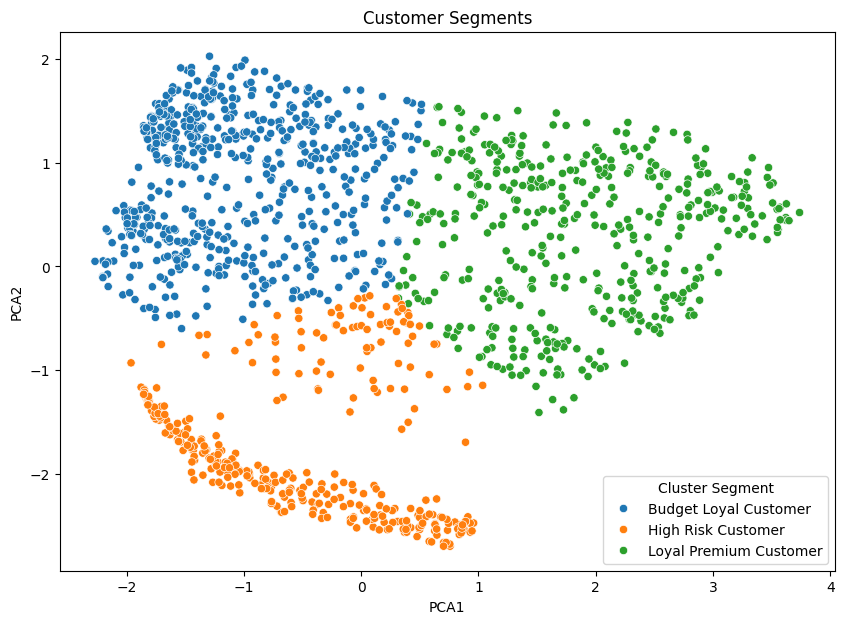

In [119]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    x="PCA1",
    y="PCA2",
    hue="Cluster Segment",
    data=Segmentio_Data
)

plt.title("Customer Segments")
plt.show()

SHAP EXPLACIBILITY

In [121]:
x = df_encoded.drop('Churn Value', axis=1)
y = df_encoded['Churn Value']

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [122]:
rf_tuned = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

rf_tuned.fit(x_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=300,
                       random_state=42)

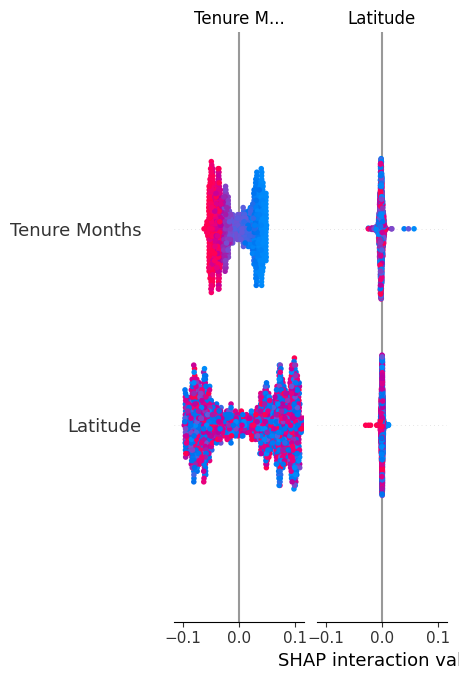

In [123]:
import shap

explainer = shap.TreeExplainer(rf_tuned)
shap_values = explainer.shap_values(x_test)
shap.summary_plot(shap_values, x_test)